In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
X= dataset.iloc[:,[3,4]].values 

In [14]:
#model creation:
#unlike kmeans and agglomerative, affinity propagation does not require us to specify the number of clusters (n_clusters). 
#It automatically determines the number of clusters based on the dataset.(Doesn't need Elbow method or Dendrogram step)
from sklearn.cluster import OPTICS
op=OPTICS(min_samples=2,xi=0.05, min_cluster_size=0.05)
output=op.fit_predict(X)

C:\Anaconda3\envs\aiml\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


In [15]:
output

array([-1,  3,  4,  3, -1,  3,  4, -1,  4,  3,  4, -1,  4,  3,  4,  3, -1,
        3, -1, -1, -1,  3,  4,  3,  4, -1, -1, -1, -1, -1,  4,  3,  4, -1,
        4, -1,  4,  3, -1,  3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  0, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0,  0,
       -1,  0, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1,  2,  1,  2,  2,  1,  1,  1,  2,  1,  2,  1,
       -1,  1,  1,  2,  1,  1,  2,  1,  1,  1,  2,  1,  1,  1,  2, -1,  2,
       -1, -1, -1, -1,  8, -1,  7, -1,  8,  5,  7,  5,  7, -1,  7,  5,  8,
        5,  7,  5,  7,  5,  8, -1,  8,  5,  8, -1,  7,  5,  8,  5,  8,  5,
        7,  5,  8, -1,  7, -1,  7, -1, -1, -1,  8,  6, -1,  6, -1,  6, -1,
        6, -1,  6, -1,  6, -1,  6, -1,  6, -1, -1, -1,  6, -1, -1, -1,  6,
       -1,  6, -1,  6, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [16]:
#Creating an empty table and copying the dataset table values:
supervised=pd.DataFrame(dataset)

In [17]:
#in that supervised table, create a new column name Cluster_group and then enter the values from output:
supervised["Cluster_group"]=output

In [18]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [19]:
#Giving the newly created table a name as "Cluster.csv":
#index=False ensures that your exported files contain only your actual data rather than an extra, unnamed column of numbers.
supervised.to_csv("Cluster.csv",index=False)

C:\Anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


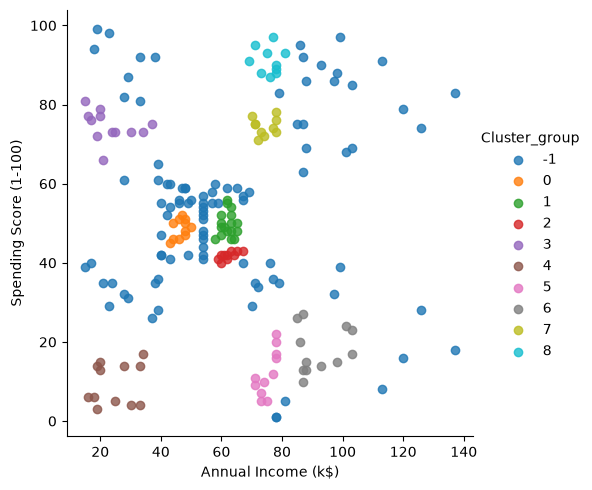

In [20]:
import seaborn as sns
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)
